In [15]:
pip install -r requirements.txt


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [17]:
df = pd.read_csv("../Data/batch-1-10.csv")
df = df.rename(columns={
"Time (h)": "time",
"Aeration rate(Fg:L/h)": "aeration",
"Agitator RPM(RPM:RPM)": "rpm",
"Sugar feed rate(Fs:L/h)": "feed_rate",
"Dissolved oxygen concentration(DO2:mg/L)": "do",
"Penicillin concentration(P:g/L)": "penicillin",
"Offline Biomass concentratio(X_offline:X(g L^{-1}))": "biomass",
"Carbon evolution rate(CER:g/h)": "cer",
"Oxygen Uptake Rate(OUR:(g min^{-1}))": "our",
"Temperature(T:K)": "temp",
"pH(pH:pH)": "ph"
})
df.head()

,time,aeration,rpm,feed_rate,Acid flow rate(Fa:L/h),Base flow rate(Fb:L/h),Heating/cooling water flow rate(Fc:L/h),Heating water flow rate(Fh:L/h),Water for injection/dilution(Fw:L/h),Air head pressure(pressure:bar),...,our,Oxygen in percent in off-gas(O2:O2 (%)),Offline Penicillin concentration(P_offline:P(g L^{-1})),biomass,cer,Ammonia shots(NH3_shots:kgs),Viscosity(Viscosity_offline:centPoise),Fault reference(Fault_ref:Fault ref),0 - Recipe driven 1 - Operator controlled(Control_ref:Control ref),batch_id
0,0.2,30,100,8,0.0000,30.118,9.8335,0.0001,0,0.6,...,0.480510,0.19595,NaN,NaN,0.034045,0,NaN,0,0,1
1,0.4,30,100,8,0.0000,51.221,18.1550,0.0001,0,0.6,...,0.058147,0.20390,NaN,NaN,0.038702,0,NaN,0,0,1
2,0.6,30,100,8,0.0000,54.302,9.5982,0.0001,0,0.6,...,-0.041505,0.20575,NaN,NaN,0.040240,0,NaN,0,0,1
3,0.8,30,100,8,0.0000,37.816,4.3395,0.0001,0,0.6,...,-0.056737,0.20602,NaN,NaN,0.041149,0,NaN,0,0,1
4,1.0,30,100,8,0.5181,18.908,1.1045,0.0001,0,0.6,...,-0.049975,0.20589,1.017800e-25,0.52808,0.041951,0,4.083,0,0,1


Text(0.5, 1.0, 'Time step size')

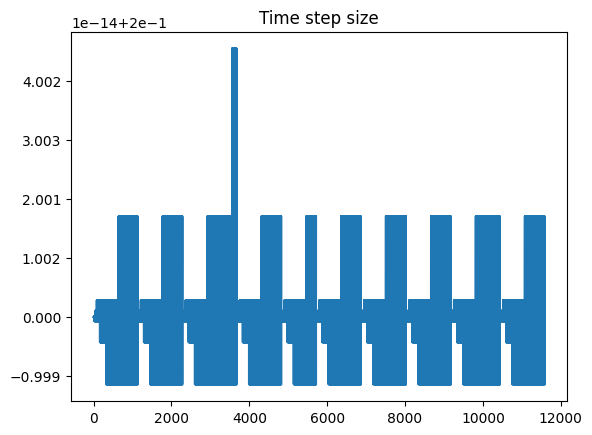

In [18]:
df["dt"] = df.groupby("batch_id")["time"].diff()
plt.plot(df["dt"])
plt.title("Time step size")
#time step is constant at 0.2

In [19]:
df["dt"] = 0.2 #remove noise

Text(0.5, 1.0, 'Cumulative substrate feed per batch')

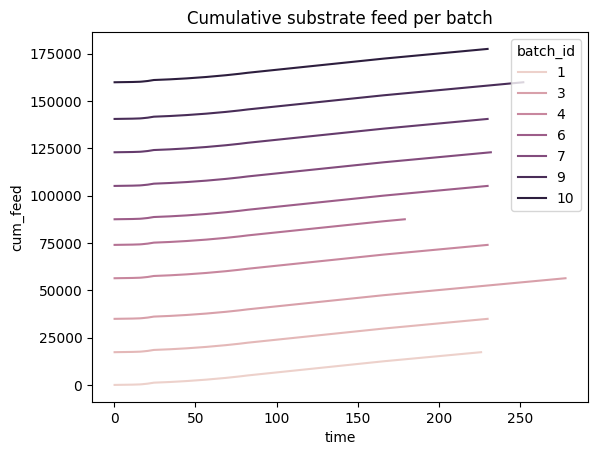

In [20]:
df["cum_feed"] = (df["feed_rate"] * df["dt"]).cumsum()
sns.lineplot(data=df, x="time", y="cum_feed", hue="batch_id")
plt.title("Cumulative substrate feed per batch")
#shows that batch feed was done continously measured, not batchwise

In [21]:
#YO BIOMASS IS ALMOST ENTIRELY NaN
# interpolate biomass within each batch, to fill the periodic NaN values
df["biomass"] = df.groupby("batch_id")["biomass"].transform(lambda x: x.interpolate())
# compute growth rate
df["growth_rate"] = df.groupby("batch_id")["biomass"].diff() / df["dt"]
df["growth_rate"] = df["growth_rate"].fillna(0)
# graphs look fine

<Axes: xlabel='time', ylabel='penicillin_rate'>

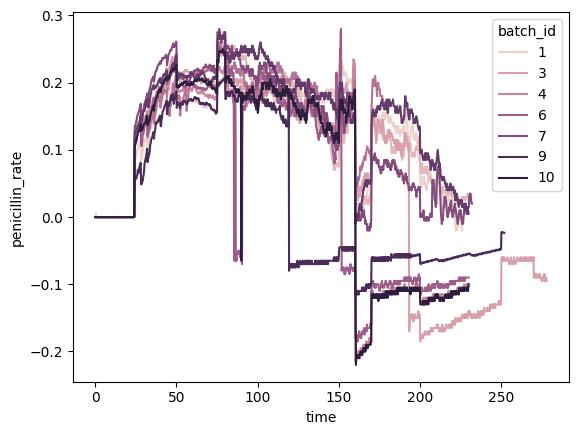

In [22]:
#Penicillin rate
df["penicillin_rate"] = df.groupby("batch_id")["penicillin"].diff() / df["dt"]
df["penicillin_rate"] = df["penicillin_rate"].fillna(0)
#This removes unrealistic derivative spikes:
# df["penicillin_rate"] = df["penicillin_rate"].clip(lower=-0.05)
#But SHOULD WE???
sns.lineplot(data=df, x="time", y="penicillin_rate", hue="batch_id")

<Axes: xlabel='time', ylabel='mixing_intensity'>

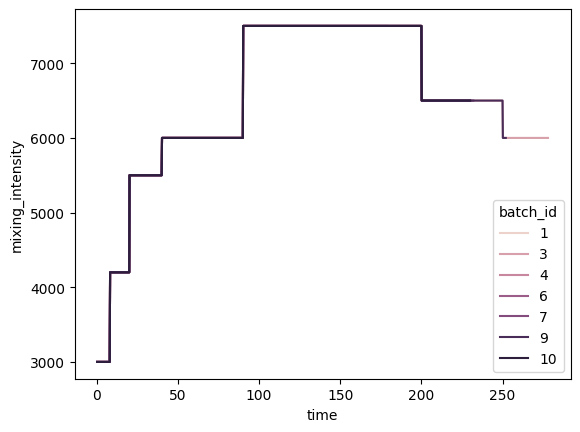

In [23]:
#and because negative values are impossible?
df["oxygen_efficiency"] = df["our"] / (df["aeration"].clip(lower=0.01))
df["oxygen_efficiency"] = df["oxygen_efficiency"].clip(lower=0)

#not needed for this dataset, since RPM is constant, but would be useful for other datasets
df["mixing_intensity"] = df["rpm"] * df["aeration"]
sns.lineplot(data=df, x="time", y="mixing_intensity", hue="batch_id")

In [24]:
#smoothening
df["biomass_smooth"] = (
    df.groupby("batch_id")["biomass"]
    .transform(lambda x: x.rolling(5).mean()))

df["penicillin_smooth"] = (
    df.groupby("batch_id")["penicillin"]
    .transform(lambda x: x.rolling(5).mean()))
# Backfill smoothing features
df["biomass_smooth"] = df["biomass_smooth"].bfill()
df["penicillin_smooth"] = df["penicillin_smooth"].bfill()
# add a lag step
df["biomass_lag1"] = df.groupby("batch_id")["biomass"].shift(1)
df["penicillin_lag1"] = df.groupby("batch_id")["penicillin"].shift(1)
df["our_lag1"] = df.groupby("batch_id")["our"].shift(1)
# Fill lag features with 0
df["biomass_lag1"] = df["biomass_lag1"].fillna(0)
df["penicillin_lag1"] = df["penicillin_lag1"].fillna(0)
df["our_lag1"] = df["our_lag1"].fillna(0)